In [1]:
#IRAC forced photometry following Kristina Nylands python script using tractor


In [16]:
import numpy as np
import pandas as pd

from tractor import *
#from tractor import NCircularGaussianPSF, NullWCS, NullPhotoCal, ConstantSky, PixPos,Flux,GalaxyShape, PointSource
from tractor.mix import *
from tractor.galaxy import *
from tractor.sersic import *

from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import seaborn as sns

from astropy.nddata import Cutout2D
from astropy.stats import sigma_clipped_stats
import astropy.wcs as wcs
import astropy.io.fits as fits

import math

import sys
import os
from contextlib import contextmanager
#!{sys.executable} -m pip install -U photutils
#from photutils.centroids import centroid_com, centroid_quadratic

#!{sys.executable} -m pip install -U reproject
from reproject import reproject_interp

from skimage.transform import rotate



In [3]:
# set up clean catalog with fiducial band fluxes, ra, dec, shape parameters, probability that it is a star

#read in the catalog I generated from IRSA website
#COSMOS 2015 with only some of the columns and a few rows
#Type: 0 = galaxy, 1 = star, 2 = X-ray source
#I think the center of this catalog is roughy 149.955, 3.5375
df = pd.read_csv('table_irsa_catalog_search_results.csv')

# set default cutout width = 10"
cutout_width = 10

ra_0 = df.ra[0]
dec_0 = df.dec[0]

In [4]:
#are there missing values
df.isna().sum()

#don't mind that there are missing values for IRAC flues or for photzs.  
#The rest of the rows are complete

ra                     0
dec                    0
ks_flux_aper2          0
ks_fluxerr_aper2       0
splash_1_flux          0
splash_1_flux_err      0
splash_2_flux          4
splash_2_flux_err      4
splash_3_flux          1
splash_3_flux_err      1
splash_4_flux          1
splash_4_flux_err      1
photoz               103
type                   0
dist                   0
angle                  0
dtype: int64

In [5]:
#ot of curiosity how many stars vs. galaxies vs. x ray sources
df.type.value_counts()

0    233
1     26
2     18
Name: type, dtype: int64

In [6]:
# initialize columns in data frame for photometry results
df[["ch1flux","ch1flux_unc","ch2flux","ch2flux_unc","ch3flux","ch3flux_unc","ch4flux","ch4flux_unc"]] = 0.0
df

,ra,dec,ks_flux_aper2,ks_fluxerr_aper2,splash_1_flux,splash_1_flux_err,splash_2_flux,splash_2_flux_err,splash_3_flux,splash_3_flux_err,...,dist,angle,ch1flux,ch1flux_unc,ch2flux,ch2flux_unc,ch3flux,ch3flux_unc,ch4flux,ch4flux_unc
0,149.965822,2.531597,214.326,0.206,125.964,1.339,86.027,0.624,53.593,6.518,...,20.980209,139.071517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,149.959803,2.545853,200.022,0.202,229.210,0.663,213.566,0.649,133.877,8.212,...,36.338671,347.444316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,149.964342,2.524065,39.683,0.201,101.392,0.391,84.348,0.305,56.682,5.627,...,43.783967,168.908324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,149.974577,2.535126,179.502,0.202,178.545,0.980,159.020,0.583,93.677,8.478,...,45.342368,93.978393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,149.964045,2.549669,554.188,0.215,265.029,4.806,167.963,1.731,122.502,9.193,...,49.755392,8.501218,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,149.947733,2.617537,784.587,0.211,403.274,5.183,268.914,4.217,176.142,9.653,...,297.982940,350.085037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
273,149.967699,2.618600,117.667,0.201,118.720,0.556,107.478,0.372,70.513,5.605,...,298.065477,3.942609,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
274,150.029173,2.584542,3868.596,0.142,2222.299,25.874,1550.527,20.617,1050.171,37.954,...,298.160103,54.117628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
275,149.986724,2.615151,1015.520,0.207,587.694,6.929,402.288,3.112,267.335,8.117,...,298.492791,17.330013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
#function to determine what type of source it is from catalog
def determine_source_type(ra, dec, df_type, fid_flux, x1,y1):
    #make all sources point sources for now
    #use fiducial flux as first guess of source flux in different bands
        
    src = PointSource(PixPos(x1,y1), Flux(fid_flux))
    return src
    

In [8]:
##function to extract cutout image

def extract_cutout(infile, ra, dec, cutout_width):
    '''
    infile: mosaic containing catalog source
    outfile: cutout fits file of source
    ra: RA of source being modeled  
    dec: DEC of source being modeled  
    cutout_width: desired width of cutout in arcseconds
    '''
    if not os.path.isfile(infile):
        error_message = 'ERROR: FITS FILE {} NOT FOUND - ABORTING SCRIPT'.format(infile)
        sys.exit(error_message)
    else:
        try:
            #open the mosaic file
            hdulist = fits.open(infile)[0]
            hdr = hdulist.header
            wcs_info = wcs.WCS(hdulist)
            
            #convert ra and dec into x, y 
            x0, y0 = wcs_info.all_world2pix(ra, dec,1)
            position=(x0, y0)
            #subimage = hdulist[0].data
            
            #make size array in pixels
            #how many 0.6" pixels in cutout_width
            mosaic_pix_scale = 0.6 #arseconds/pixel is the standard mosaic pixel scale
            size = (cutout_width / mosaic_pix_scale)
            size = int(math.ceil(size)) #round up the nearest integer
            
            #make the cutout
            cutout = Cutout2D(hdulist.data, position, size, copy = True, mode = "trim", wcs = wcs_info)
            subimage = cutout.data.copy()
            subimage_wcs = cutout.wcs.copy()
            
            #now need to set the values of x1, y1 at the location of the target *in the cutout*          
            x1, y1 = subimage_wcs.all_world2pix(ra, dec,1)
            #print('x1, y1', x1, y1)
            
            #hdulist.close()
            nodata_param = False
            
        except (Exception, error):
            nodata_param = True
            subimage = numpy.empty([10,10])
            subimage[:] = 0.0

    return subimage.data, hdr, nodata_param, x1, y1, subimage_wcs







In [9]:
#function to make the PRF the same pixel scale as the mosaic images
#tractor expects this, and will give bad results if the pixel scale is anything else
def prepare_PRF(prf_fitsname, ra_0, dec_0, rotate_angle):
    
    #read in the PRF fits file
    ext_prf =  fits.open(prf_fitsname)[0]

    #fix a type on the header that crashes reproject_interp 
    ext_prf.header['CTYPE1'] = 'RA---TAN'
    
    #ok, need to fake it and make the ra and dec of the center of the prf 
    #be the same as the center of the cutout
    #just using a random cutout here to make this work since we need an image
    #for reproject_interp to work
    ext_prf.header['CRVAL1'] = ra_0
    ext_prf.header['CRVAL2'] = dec_0

    cutout = fits.open('0001_149.96582000_2.53160000_irac_ch1_go2_sci_10.fits')[0]

    prf_resample, footprint = reproject_interp(ext_prf, cutout.header)

    #ugg, ok, and check if it is an odd size
    #tractor crashes if the PRF has an even number of pixels
    if (len(prf_resample.data) % 2) < 1:
        prf_resample=Cutout2D(prf_resample, (9,9), (17,17)) 
    
        #and because cutout2D changes data types
        prf_resample = prf_resample.data
    
    #renormalize the PRF so that the sum of all pixels = 1.0
    #again, tractor gives anomolous results if the PRF is normalized any other way
    prf_resample_norm = prf_resample / prf_resample.sum()

    #looks like a rotation might help
    #still working to figure this out, but setting up to let it happen here
    prf_resample_norm_rotate = rotate(prf_resample_norm, rotate_angle)
       
    return prf_resample_norm_rotate



In [10]:
#function to figure out how many sources are in cutout
def find_nconfsources(raval, decval, gal_type, fluxval, x1, y1, cutout_width, subimage_wcs):
    
    #setup to collect sources
    objsrc = []
    
    #keep the main source
    objsrc.append(determine_source_type(raval, decval, gal_type, fluxval, x1, y1))
    
    #find confusing sources with real fluxes
    radiff = (df.ra-raval)*np.cos(decval)
    decdiff= df.dec-decval
    posdiff= np.sqrt(radiff**2+decdiff**2)*3600.
    det = df.ks_flux_aper2 > 0  #make sure they have fluxes
    
    #make an index into the dataframe for those objects within the same cutout
    good = (abs(radiff*3600.) < cutout_width/2) & (abs(decdiff*3600.) < cutout_width/2) & (posdiff > 0.2) & det
    nconfsrcs = np.size(posdiff[good])

    #add confusing sources
    #if there are any confusing sources
    if nconfsrcs > 0:
        ra_conf = df.ra[good].values
        dec_conf = df.dec[good].values
        flux_conf = df.ks_flux_aper2[good].values #should all be real fluxes
        type_conf = df.type[good].values

        for n in range(nconfsrcs):
            #now need to set the values of x1, y1 at the location of the target *in the cutout*          
            xn, yn = subimage_wcs.all_world2pix(ra_conf[n], dec_conf[n],1)
            objsrc.append(determine_source_type(ra_conf[n], dec_conf[n], type_conf[n], flux_conf[n], xn, yn))
                
            
    return objsrc, nconfsrcs
    
#calling sequence
#find_nconfsources(df.ra[i], df.dec[i], df.type[i], df.ks_flux_aper2[i], x1,y1, cutout_width, subimage_wcs)

In [17]:
#setup to suppress output from tractor
#seems to be the only way to make it be quiet

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout


sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
flux 9.312265790760865
the tractor flux of the source is 78.79662214709475 MicroJy
The splash flux of the source is 89.065 MicroJy
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
flux 6.074465815297043
the tractor flux of the source is 51.39966989218601 MicroJy
The splash flux of the source is 61.803 MicroJy
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
sparse columns: 6 rows 289
len(X) 6
flux 5.610999988348608
the tractor flux of the source is 47.478009743655946 MicroJy
The splash flux of the source is 53.855 Mi

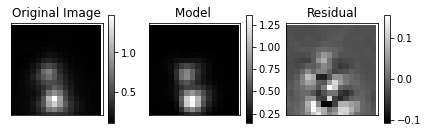

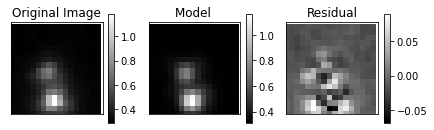

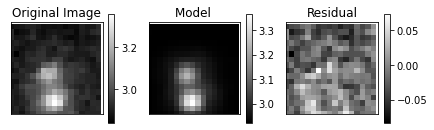

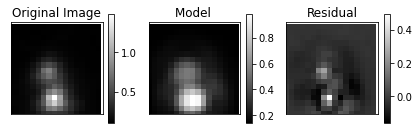

In [11]:
verbose = 1
rotate_angle = 0  #might want to rotate the PRF image - still needs testing
#for each object in the catalog
for i in range(11,12):

    #for each band
    for j in range(1,5):
        
        #extract the cutout & choose prf
        if j == 1:
            infile = 'COSMOS_irac_ch1_mosaic_test.fits'
            prf = prepare_PRF('IRAC.1.EXTPRF.5X.fits', ra_0, dec_0, rotate_angle)
            ch_flux = 'ch1flux'
            splash_flux = df.splash_1_flux[i]
        elif j == 2:
            infile = 'COSMOS_irac_ch2_mosaic_test.fits'
            prf = prepare_PRF('IRAC.2.EXTPRF.5X.fits', ra_0, dec_0, rotate_angle)
            ch_flux = 'ch2flux'
            splash_flux = df.splash_2_flux[i]
        elif j == 3:
            infile = 'COSMOS_irac_ch3_mosaic_test.fits'
            prf = prepare_PRF('IRAC.3.EXTPRF.5X.fits', ra_0, dec_0, rotate_angle)
            ch_flux = 'ch3flux'
            splash_flux = df.splash_3_flux[i]
        elif j == 4:
            infile = 'COSMOS_irac_ch4_mosaic_test.fits'
            prf = prepare_PRF('IRAC.4.EXTPRF.5X.fits', ra_0, dec_0, rotate_angle)
            ch_flux = 'ch4flux'
            splash_flux = df.splash_4_flux[i]

        else:
            print("That band doesn't exist")
        
        
        #make a cutout
        subimage, hdr, nodata_param, x1,y1, subimage_wcs = extract_cutout(infile, df.ra[i], df.dec[i], cutout_width)
        
        #catch errors in nodata_param
        
        #set up the source list
        #src = determine_source_type(df.ra[i], df.dec[i], df.type[i], df.ks_flux_aper2[i], x1,y1)
        objsrc, nconfsrcs = find_nconfsources(df.ra[i], df.dec[i], df.type[i], df.ks_flux_aper2[i], x1,y1, cutout_width, subimage_wcs)

        #measure sky noise and mean level
        mean, median, std = sigma_clipped_stats(subimage, sigma=3.0)
        

        #make the tractor image
        tim=Image(data=subimage, invvar=np.ones_like(subimage) / std**2, 
          psf=PixelizedPSF(prf) ,
          wcs=NullWCS(),photocal=NullPhotoCal(),sky=ConstantSky(mean))
        
        
        # make tractor object
        tractor=Tractor([tim], objsrc) #[src]

        #freeze the parameters we don't want tractor fitting
        tractor.freezeParam('images')
        #only fit for brightness
        #src.freezeAllRecursive()
        #src.thawPathsTo('brightness')


        #run the tractor optimization (do forced photometry)
        # Take several linearized least squares steps
        for tr in range(20):
            dlnp,X,alpha, flux_var=tractor.optimize(variance = True)
            #print('dlnp',dlnp)
            if dlnp < 1e-3:
                break


        # catch exceptions and bad fits
        
        
        # determine flux uncertainty
        
        
        # record the photometry results
        params_list=objsrc[0].getParamNames()
        bindex = params_list.index('brightness.Flux')
        flux = objsrc[0].getParams()[bindex]
        print("flux", flux)
        #convert to microjanskies
        microJy = flux *(1E12) / (4.254517E10) * (0.6) *(0.6)
        print("the tractor flux of the source is", microJy, 'MicroJy')
        print("The splash flux of the source is", splash_flux,'MicroJy')
        df.at[i,ch_flux]= microJy
        
        if verbose == 1:
            #look at residual images
            # Get the fit model and residual images for plotting
            mod=tractor.getModelImage(0)
            chi = tractor.getChiImage(0)
            diff=subimage-mod

            fig=plt.figure(figsize=(7,2))

            ax1=fig.add_subplot(131,autoscale_on=False,xlim=(0,17),ylim=(0,17))
            ax2=fig.add_subplot(132,autoscale_on=False,xlim=(0,17),ylim=(0,17))
            ax3=fig.add_subplot(133,autoscale_on=False,xlim=(0,17),ylim=(0,17))

            ax1.set(xticks=[],yticks=[])
            ax2.set(xticks=[],yticks=[])
            ax3.set(xticks=[],yticks=[])

            im1=ax1.imshow(subimage,cmap='gray')#, vmin = 0.01, vmax = 0.20
            ax1.set_title('Original Image')
            fig.colorbar(im1, ax= ax1)

            im2=ax2.imshow(mod,cmap='gray')#, vmin = 0.01, vmax = 0.20
            ax2.set_title('Model ')
            fig.colorbar(im2, ax = ax2)

            im3 = ax3.imshow(diff,cmap = 'gray')#, vmin = 0.01, vmax = 0.20
            ax3.set_title('Residual')
            fig.colorbar(im3, ax = ax3)



In [12]:
#just checking that df is getting filled in properly
df.head(12)

,ra,dec,ks_flux_aper2,ks_fluxerr_aper2,splash_1_flux,splash_1_flux_err,splash_2_flux,splash_2_flux_err,splash_3_flux,splash_3_flux_err,...,dist,angle,ch1flux,ch1flux_unc,ch2flux,ch2flux_unc,ch3flux,ch3flux_unc,ch4flux,ch4flux_unc
0,149.965822,2.531597,214.326,0.206,125.964,1.339,86.027,0.624,53.593,6.518,...,20.980209,139.071517,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
1,149.959803,2.545853,200.022,0.202,229.210,0.663,213.566,0.649,133.877,8.212,...,36.338671,347.444316,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
2,149.964342,2.524065,39.683,0.201,101.392,0.391,84.348,0.305,56.682,5.627,...,43.783967,168.908324,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
3,149.974577,2.535126,179.502,0.202,178.545,0.980,159.020,0.583,93.677,8.478,...,45.342368,93.978393,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
4,149.964045,2.549669,554.188,0.215,265.029,4.806,167.963,1.731,122.502,9.193,...,49.755392,8.501218,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
5,149.965258,2.521661,45.945,0.203,85.807,0.603,76.941,0.338,49.733,3.790,...,52.932381,167.211382,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
6,149.958566,2.520407,38.610,0.201,68.976,0.488,49.192,0.357,45.426,6.326,...,57.477556,192.407840,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
7,149.944833,2.536300,60.410,0.203,99.115,0.492,62.569,0.257,38.939,3.529,...,61.749006,271.002359,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
8,149.970093,2.520146,160.973,0.211,80.449,1.097,53.301,0.444,37.375,5.174,...,64.065960,152.979508,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0
9,149.945399,2.527761,41.316,0.204,62.590,0.351,42.638,0.290,35.618,5.238,...,66.666837,243.584102,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0


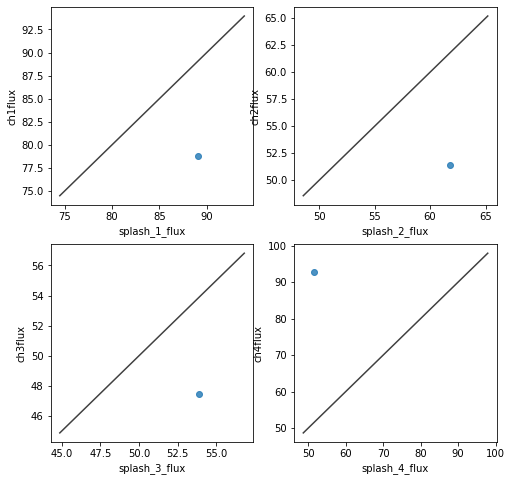

In [13]:
#plot tractor fluxes vs. catalog splash fluxes
#and hope I see a straightline with a slope of 1
#using sns regplot which plots both the data and a linear regression model fit
#need to still add uncertainties to the plotting and regression

#first shrink the dataframe to only those rows where I have tractor photometry while testing
df_tractor = df[df.ch1flux> 0]

#setup to plot
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

#ch1 
sns.regplot(data = df_tractor, x = "splash_1_flux", y = "ch1flux", ax = ax1)
#add a diagonal line with y = x
lims = [
    np.min([ax1.get_xlim(), ax1.get_ylim()]),  # min of both axes
    np.max([ax1.get_xlim(), ax1.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax1.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

#ch2 
sns.regplot(data = df_tractor, x = "splash_2_flux", y = "ch2flux", ax = ax2)
#add a diagonal line with y = x
lims = [
    np.min([ax2.get_xlim(), ax2.get_ylim()]),  # min of both axes
    np.max([ax2.get_xlim(), ax2.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax2.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

#ch3 
sns.regplot(data = df_tractor, x = "splash_3_flux", y = "ch3flux", ax = ax3)
#add a diagonal line with y = x
lims = [
    np.min([ax3.get_xlim(), ax3.get_ylim()]),  # min of both axes
    np.max([ax3.get_xlim(), ax3.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax3.plot(lims, lims, 'k-', alpha=0.75, zorder=0)

#ch4 
sns.regplot(data = df_tractor, x = "splash_4_flux", y = "ch4flux", ax = ax4)
#add a diagonal line with y = x
lims = [
    np.min([ax4.get_xlim(), ax4.get_ylim()]),  # min of both axes
    np.max([ax4.get_xlim(), ax4.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax4.plot(lims, lims, 'k-', alpha=0.75, zorder=0)





fig.set_size_inches(8, 8)

In [14]:
microJy = 53 *(1E12) / (4.254517E10) * (0.6) *(0.6)
microJy

448.4645378076994